In [1]:
from upconversion_models.ions.erbium import ErIon
from jablonski import SingletState
from upconversion_models.utils import h,c, k
import numpy as np
import pint 


u = pint.get_application_registry()
er = ErIon()

In [2]:
levels = [l for l in er._yield(SingletState)][:10]
levels

[Er1, Er2, Er3, Er4, Er5, Er6s, Er6h, Er7, Er8, Er9]

In [3]:
phonon_wavenumber = 300 / u.cm
T = 293.15 * u.K

P = np.empty((len(levels), len(levels)))
BR = P.copy()
M = P.copy()

for i, Li in enumerate(levels):
    for j, Lj in enumerate(levels):
        # from i to j

        down = Li.energy > Lj.energy

        phonon_E = h * c * phonon_wavenumber

        dE = abs(Li.energy - Lj.energy)

        x = phonon_E / (k * T)

        p = np.ceil(dE / phonon_E)

        n = 1 / np.expm1(x)

        P[i,j] = p

        BR[i,j] = dE/(k * T )

        if down:
            M[i,j] = (1+n) ** p 
        else:
            M[i,j] = n**p

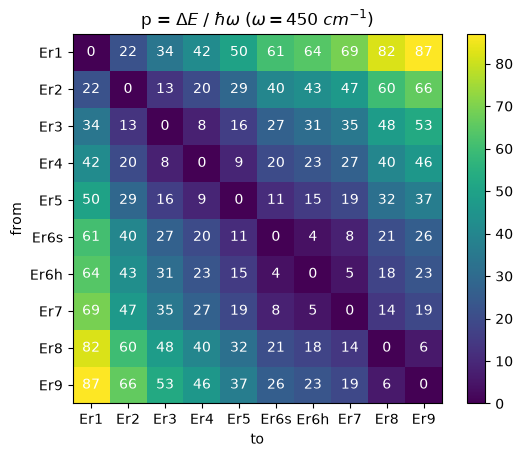

In [4]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

im = plt.imshow(P * (P>0))
ax = plt.gca()

for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        text = ax.text(j, i, int(P[i, j]),
                       ha="center", va="center", color="w")

plt.colorbar(im)

plt.xticks(np.arange(0,10), [i.__repr__() for i in levels])
plt.yticks(np.arange(0,10), [i.__repr__() for i in levels])

plt.ylabel('from')
plt.xlabel('to')


plt.title(r"p = $\Delta E$ / $\hbar \omega$ ($\omega = 450 \  cm^{-1}$)")
plt.show()

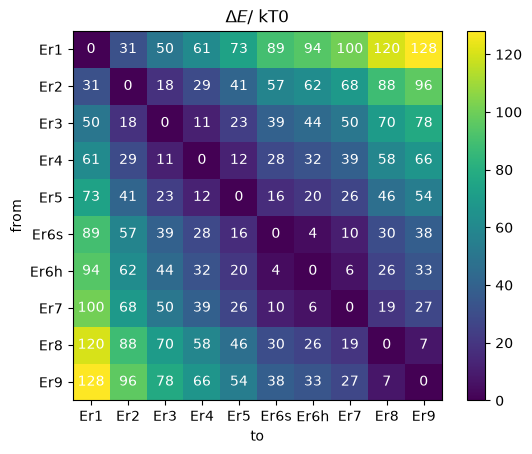

In [5]:
im = plt.imshow(BR * (P>0))
ax = plt.gca()

for i in range(BR.shape[0]):
    for j in range(BR.shape[1]):
        text = ax.text(j, i, int(BR[i,j]),
                       ha="center", va="center", color="w", fontsize=10)

plt.colorbar(im)

plt.xticks(np.arange(0,10), [i.__repr__() for i in levels])
plt.yticks(np.arange(0,10), [i.__repr__() for i in levels])

plt.ylabel('from')
plt.xlabel('to')

plt.title(r'$\Delta E$/ kT0')
plt.show()

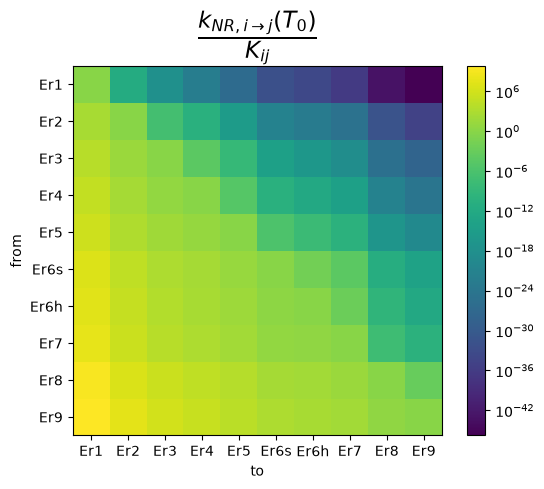

In [6]:
im = plt.imshow(M, norm=LogNorm())
plt.colorbar(im)

plt.xticks(np.arange(0,10), [i.__repr__() for i in levels])
plt.yticks(np.arange(0,10), [i.__repr__() for i in levels])

plt.ylabel('from')
plt.xlabel('to')

plt.title(r'$\frac{k_{NR,i\rightarrow j} (T_0)}{K_{ij}}$', fontsize=24)
plt.show()

In [7]:
transitions = [
    [(Li.energy - Lj.energy), Li.__repr__() + "->" + Lj.__repr__()]
    for Lj in levels
    for Li in levels
    if (Li.energy - Lj.energy) > 0
]
transitions

[[<Quantity(1.29118981e-21, 'joule * meter / centimeter')>, 'Er2->Er1'],
 [<Quantity(2.02617477e-21, 'joule * meter / centimeter')>, 'Er3->Er1'],
 [<Quantity(2.48305732e-21, 'joule * meter / centimeter')>, 'Er4->Er1'],
 [<Quantity(2.97966879e-21, 'joule * meter / centimeter')>, 'Er5->Er1'],
 [<Quantity(3.63519592e-21, 'joule * meter / centimeter')>, 'Er6s->Er1'],
 [<Quantity(3.81397605e-21, 'joule * meter / centimeter')>, 'Er6h->Er1'],
 [<Quantity(4.07221401e-21, 'joule * meter / centimeter')>, 'Er7->Er1'],
 [<Quantity(4.86679235e-21, 'joule * meter / centimeter')>, 'Er8->Er1'],
 [<Quantity(5.18462369e-21, 'joule * meter / centimeter')>, 'Er9->Er1'],
 [<Quantity(7.34984967e-22, 'joule * meter / centimeter')>, 'Er3->Er2'],
 [<Quantity(1.19186751e-21, 'joule * meter / centimeter')>, 'Er4->Er2'],
 [<Quantity(1.68847898e-21, 'joule * meter / centimeter')>, 'Er5->Er2'],
 [<Quantity(2.34400611e-21, 'joule * meter / centimeter')>, 'Er6s->Er2'],
 [<Quantity(2.52278624e-21, 'joule * meter / cen

In [8]:
transitions.sort(key=lambda e: e[0])

phonon_wavenumbers = [300/u.cm, 420/u.cm]
for dE, r in transitions[:10]:

    s = [f"{np.ceil(dE / (h*c*phonon_wavenumber)).magnitude} phonons with {phonon_wavenumber.magnitude} cm-1," for phonon_wavenumber in phonon_wavenumbers]
    print(r, "takes", *s)

Er6h->Er6s takes 4.0 phonons with 300 cm-1, 3.0 phonons with 420 cm-1,
Er7->Er6h takes 5.0 phonons with 300 cm-1, 4.0 phonons with 420 cm-1,
Er9->Er8 takes 6.0 phonons with 300 cm-1, 4.0 phonons with 420 cm-1,
Er7->Er6s takes 8.0 phonons with 300 cm-1, 6.0 phonons with 420 cm-1,
Er4->Er3 takes 8.0 phonons with 300 cm-1, 6.0 phonons with 420 cm-1,
Er5->Er4 takes 9.0 phonons with 300 cm-1, 6.0 phonons with 420 cm-1,
Er6s->Er5 takes 11.0 phonons with 300 cm-1, 8.0 phonons with 420 cm-1,
Er3->Er2 takes 13.0 phonons with 300 cm-1, 9.0 phonons with 420 cm-1,
Er8->Er7 takes 14.0 phonons with 300 cm-1, 10.0 phonons with 420 cm-1,
Er6h->Er5 takes 15.0 phonons with 300 cm-1, 11.0 phonons with 420 cm-1,
